In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from ISUILCC_LFPGr_Data import Dataset_ISUILCC_LFPGr

c:\Users\pgasper\AppData\Local\anaconda3\envs\cannele\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = Dataset_ISUILCC_LFPGr(is_short=True) # Load only a subset of the cells for testing purposes

Loading data for cell 2 of 65...
Loading data for cell 6 of 65...
Loading data for cell 64 of 65...
Loading data for cell 65 of 65...


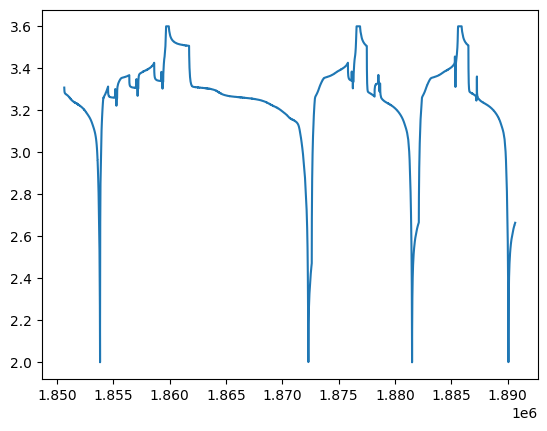

In [3]:
plt.plot(dataset[0][5].Time_s, dataset[0][5].Voltage_V)

In [4]:
dataset.cell_extracts_and_metadata_to_df()

,cell_id,__class__,Cell ID,GroupNumber,Group Channel,C_chg,C_dis,DoD,days_to_80percent_C/3_capacity,log_days_to_80percent_C/3_capacity
0,cell_2,CellData_ISUILCC_LFPGr,2,1,1,2.0,1.5,0.6,141.818391,4.954547
1,cell_6,CellData_ISUILCC_LFPGr,3,1,2,2.0,1.5,0.6,145.867176,4.982696
2,cell_64,CellData_ISUILCC_LFPGr,4,1,3,2.0,1.5,0.6,137.368947,4.922670
3,cell_65,CellData_ISUILCC_LFPGr,5,1,4,2.0,1.5,0.6,121.355382,4.798723


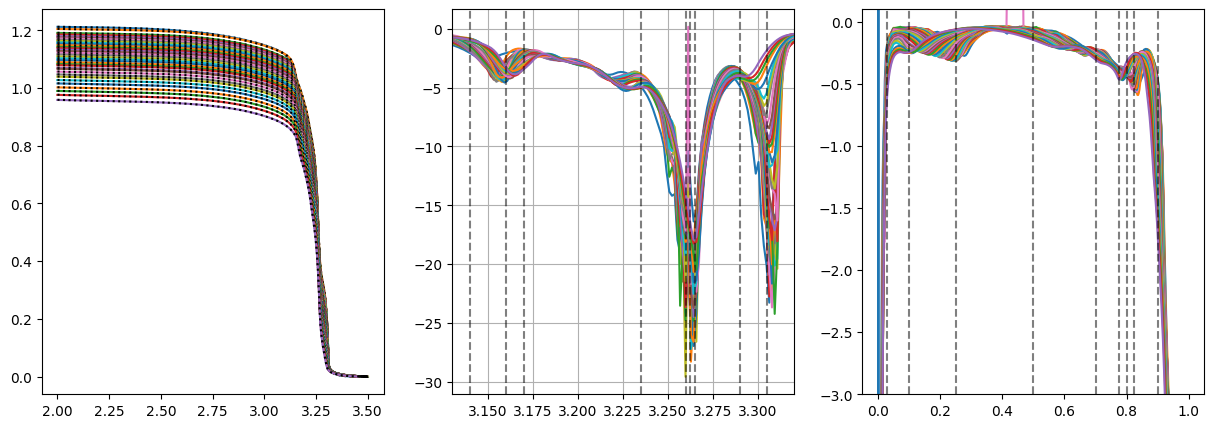

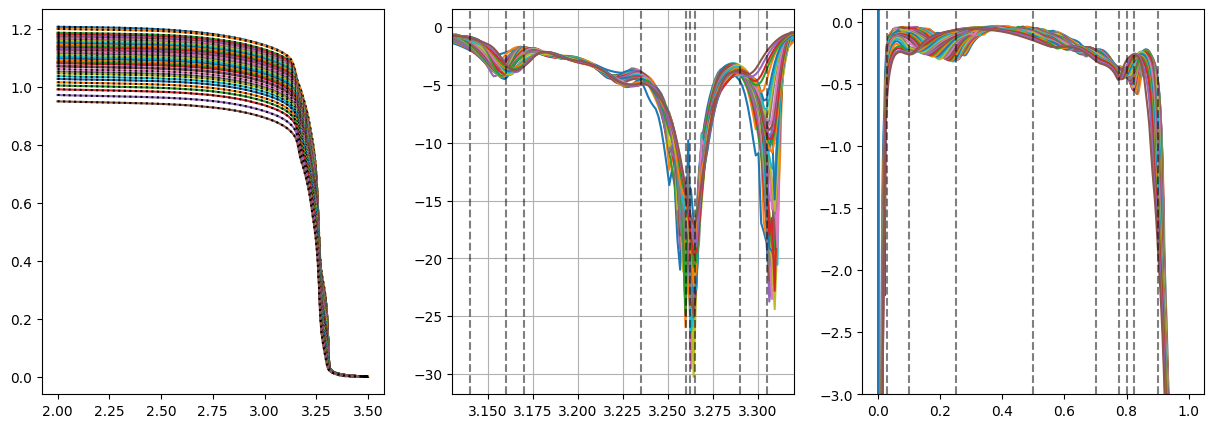

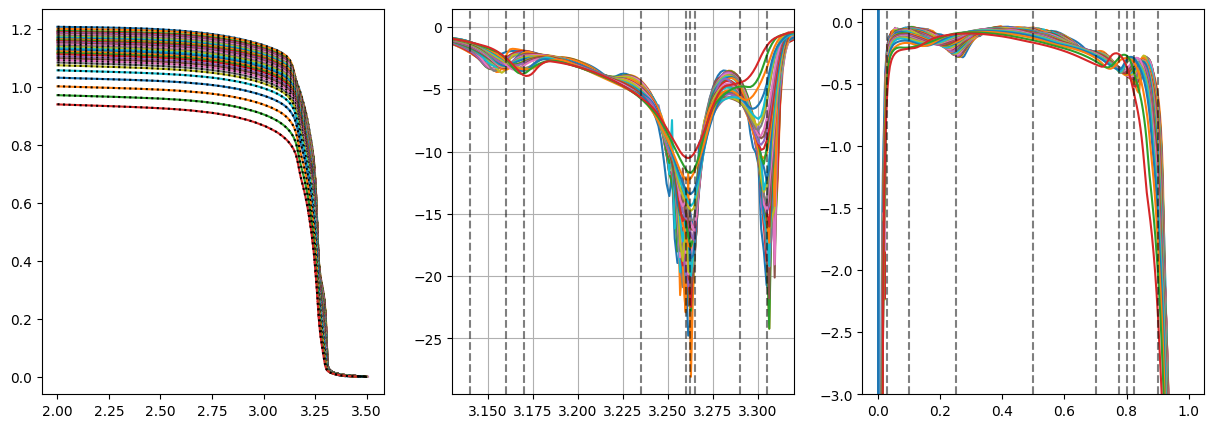

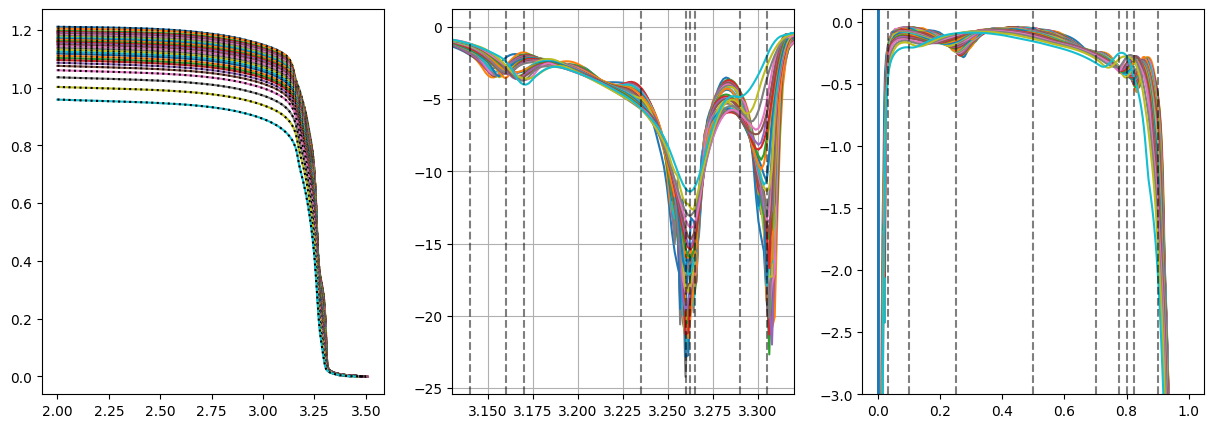

In [5]:
from ISUILCC_LFPGr_Data import get_discharge_QV_dQdV_dVdQ
for cell in dataset:
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    for i, rpt in enumerate(cell):
        rpt = cell[i]
        mask_discharge_1 = ['Discharge 1 C/3' in description for description in np.array(rpt.Step_Description)]
        Q_raw = np.array(rpt.Capacity_Ah)[mask_discharge_1]
        V_raw = np.array(rpt.Voltage_V)[mask_discharge_1]
        QV = get_discharge_QV_dQdV_dVdQ(rpt)
        line = ax[0].plot(V_raw, Q_raw, '-')
        ax[0].plot(QV['Voltage_V'], QV['Capacity_Ah'], ':k')
        ax[1].plot(QV['Voltage_V'], QV['dQdV_Ah/V'])
        ax[2].plot(QV['SOC'], QV['dVdQ_V/Ah'])

    ax[1].set_xlim(3.13, 3.32)
    ax[1].grid()
    v = [3.14, 3.16, 3.17, 3.235, 3.26, 3.2625, 3.265, 3.29, 3.305]
    for voltage in v:
        ax[1].axvline(voltage, color='k', linestyle='--', alpha=0.5)
    socs = [0.03, 0.10, 0.25, 0.50, 0.70, 0.775, 0.8, 0.825, 0.90]
    for soc in socs:
        ax[2].axvline(soc, color='k', linestyle='--', alpha=0.5)
    ax[2].set_ylim(-3, 0.1)

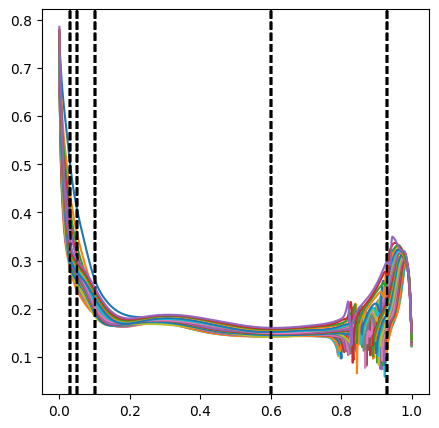

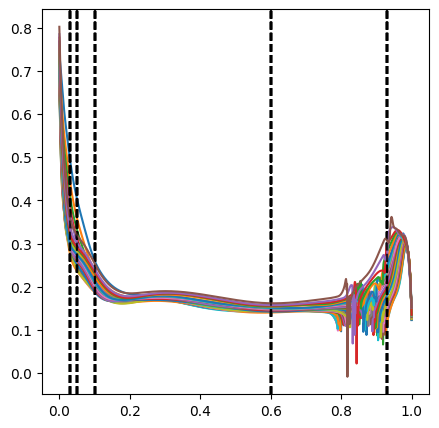

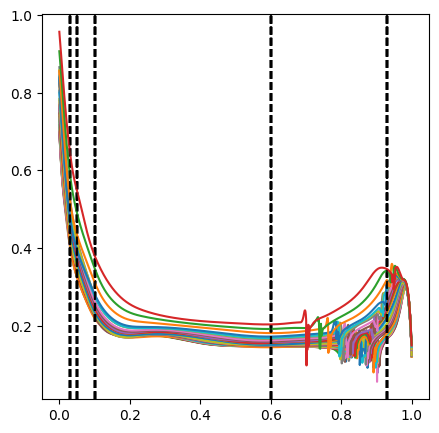

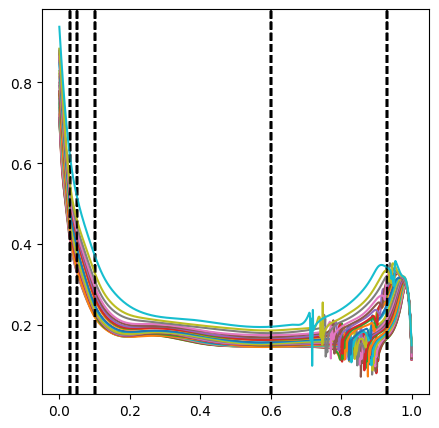

In [6]:
from ISUILCC_LFPGr_Data import get_DeltaV_SOC

for cell in dataset:
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    for i, rpt in enumerate(cell):
        deltaV_soc = get_DeltaV_SOC(rpt)
        ax.plot(deltaV_soc['SOC'], deltaV_soc['DeltaV'])

        socs = [0.03, 0.05, 0.10, 0.60, 0.93]
        for soc in socs:
            ax.axvline(soc, color='k', linestyle='--', alpha=0.5)